In [55]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import csv
import pandas as pd
from pandas.api.types import CategoricalDtype
import scipy as sp
from pathlib import Path
from tkinter import filedialog
import itertools
#from colour import Color
from datetime import date
# import statsmodels.api as sm
# from statsmodels.stats.weightstats import ztest as ztest
#from sklearn.metrics import r2_score as R2S
import cairo

## Names and Palette ##

In [56]:
today = date.today()
print("Today's date:", today)
date = str(today)
date

Today's date: 2023-10-10


'2023-10-10'

In [4]:
tubulin = '[Tubulin] ' r'$(\mu M)$'
tub = 'tub'

DCXconc = '[DCX] ' r'$(n M)$'
EBconc = '[EB] ' r'$(n M)$'
DCX = 'DCX'
Type = 'DCX Type'

Concentration = 'Concentration ' r'$(\mu M)$'
Length = 'Length ' r'$(\mu m)$'
Lifetime = 'Lifetime ' r'$(min)$'
GrowthRate = 'Growth Rate ' r'$(\mu m / min)$'
TimeToNucleate = 'Time to Nucleate ' r'$(min)$'
ShrinkageLength = 'Shrink Length ' r'$(\mu m)$'
ShrinkageLifetime = 'Shrink Lifetime ' r'$(min)$'
ShrinkageRate = 'Shrink Rate ' r'$(\mu m / min)$'

## Join Data ##

In [15]:
askdirectory = filedialog.askdirectory() # show an "Open" dialog box and return the path to the selected file
path = Path(askdirectory)

In [16]:
folders = [x for x in path.iterdir() if x.is_dir()]
folders = [i for i in folders if str(i.stem)[-1] == 'M']
folders

[WindowsPath('D:/Sofia/2023_2summer-fall_DCXintensitydynmts/2023-09-28_nonSEC-dcxdynWT/CH3_typeWT_DCX60nM'),
 WindowsPath('D:/Sofia/2023_2summer-fall_DCXintensitydynmts/2023-09-28_nonSEC-dcxdynWT/CH4_typeWT_DCX230nM'),
 WindowsPath('D:/Sofia/2023_2summer-fall_DCXintensitydynmts/2023-09-28_nonSEC-dcxdynWT/CH7_typeWT_DCX115nM'),
 WindowsPath('D:/Sofia/2023_2summer-fall_DCXintensitydynmts/2023-09-28_nonSEC-dcxdynWT/CH8_typeWT_DCX30nM')]

In [17]:
files = []
for k in folders:
    files0 = [x for x in k.iterdir() if x.is_file()]
    files0 = [i for i in files0 if str(i).rfind('Results_') != -1 if str(i).rfind('csv') != -1]
    files = files + files0
files

[WindowsPath('D:/Sofia/2023_2summer-fall_DCXintensitydynmts/2023-09-28_nonSEC-dcxdynWT/CH3_typeWT_DCX60nM/Results_processed.csv'),
 WindowsPath('D:/Sofia/2023_2summer-fall_DCXintensitydynmts/2023-09-28_nonSEC-dcxdynWT/CH4_typeWT_DCX230nM/Results_processed.csv'),
 WindowsPath('D:/Sofia/2023_2summer-fall_DCXintensitydynmts/2023-09-28_nonSEC-dcxdynWT/CH7_typeWT_DCX115nM/Results_processed.csv'),
 WindowsPath('D:/Sofia/2023_2summer-fall_DCXintensitydynmts/2023-09-28_nonSEC-dcxdynWT/CH8_typeWT_DCX30nM/Results_processed.csv')]

In [18]:
def findmetadata(tag,end,i):
    n = len(tag)
    locstart = str(i).rfind(tag) 
    locend = str(i).find(end, locstart)
    tag0 = str(i)[locstart+n: locend]
    
    return tag0

In [19]:
dates= []
CH= []
dcx = []
dcxtype= []
for i in files:
    dateloc = str(i).rfind("202")   
    dates0 = str(i)[dateloc : dateloc+10]
    dates = dates + [dates0]

    CH0 = findmetadata("CH",'_',i)
    CH = CH + [CH0]  
    
    type0 = findmetadata("type",'_',i)
    dcxtype = dcxtype + [type0] 
    
    dcx0 = findmetadata("DCX",'nM',i)
    dcx = dcx + [float(dcx0)] 

dates,CH,dcx, dcxtype

(['2023-09-28', '2023-09-28', '2023-09-28', '2023-09-28'],
 ['3', '4', '7', '8'],
 [60.0, 230.0, 115.0, 30.0],
 ['WT', 'WT', 'WT', 'WT'])

## Open Data ##

In [20]:
data = pd.DataFrame(columns=[] , index=[])

for i in np.arange(len(files)):
    data0 = pd.read_csv(files[i], encoding='utf-8',keep_default_na=False)

    
    data0['Date'] = dates[i]
    data0['CH'] = CH[i]
    data0[DCXconc] = dcx[i]
    data0['Type'] = dcxtype[i]
    
    data = pd.concat([data,data0], ignore_index=True)

data = data.rename(columns={"Mean": "Intensity"})
data = data.sort_values(by = DCXconc)
data

,,Area,Intensity,Min,Max,Angle,Length,Date,CH,[DCX] $(n M)$,Type
134,30,120,15.767,4,35,-92.386,24.021,2023-09-28,8,30.0,WT
106,2,270,23.944,6,38,173.660,54.332,2023-09-28,8,30.0,WT
107,3,332,15.774,5,37,-141.746,66.219,2023-09-28,8,30.0,WT
108,4,460,13.909,2,34,151.489,92.179,2023-09-28,8,30.0,WT
109,5,358,12.263,1,30,-41.035,71.589,2023-09-28,8,30.0,WT
...,...,...,...,...,...,...,...,...,...,...,...
55,26,175,75.640,46,102,0.000,35.500,2023-09-28,4,230.0,WT
54,25,454,70.249,20,133,87.153,90.612,2023-09-28,4,230.0,WT
53,24,286,52.350,30,66,-4.014,57.140,2023-09-28,4,230.0,WT
61,32,352,62.472,21,100,110.746,70.576,2023-09-28,4,230.0,WT


In [21]:
newdirectory = str(path.parents[0])+'//Intensity_Data_Sheets'
newmydir = Path(newdirectory)
newmydir.mkdir(exist_ok=True)
newmydir

WindowsPath('D:/Sofia/2023_2summer-fall_DCXintensitydynmts/Intensity_Data_Sheets')

In [22]:
name = dates[0]+'_Intensity_analysed-on_'+date +'.csv'
name

'2023-09-28_Intensity_analysed-on_2023-10-10.csv'

In [23]:
data.to_csv(path/(name), encoding='utf-8', index=False)
data.to_csv(newmydir/(name), encoding='utf-8', index=False)

## Open prev sevad data ##

In [24]:
askFitParam = filedialog.askopenfilename() # show an "Open" dialog box and return the path to the selected file
data = pd.read_csv(askFitParam, encoding='utf-8',keep_default_na=False)
data

,,Area,Intensity,Min,Max,Angle,Length,Date,CH,[DCX] $(n M)$,Type
0,8,130,15.946,3,29,-62.447,25.942,2023-10-04,8,30,WT
1,1,265,25.411,10,38,-88.919,53.009,2023-10-04,4,30,WT
2,2,112,23.259,9,38,144.162,22.204,2023-10-04,4,30,WT
3,4,143,20.867,5,33,36.469,28.601,2023-10-04,4,30,WT
4,5,240,22.913,2,38,153.435,44.721,2023-10-04,4,30,WT
...,...,...,...,...,...,...,...,...,...,...,...
374,26,175,75.640,46,102,0.000,35.500,2023-09-28,4,230,WT
375,25,454,70.249,20,133,87.153,90.612,2023-09-28,4,230,WT
376,24,286,52.350,30,66,-4.014,57.140,2023-09-28,4,230,WT
377,32,352,62.472,21,100,110.746,70.576,2023-09-28,4,230,WT


## Plot ##

In [25]:
grey00 = '#777777'
grey20 = '#C5C5C5'

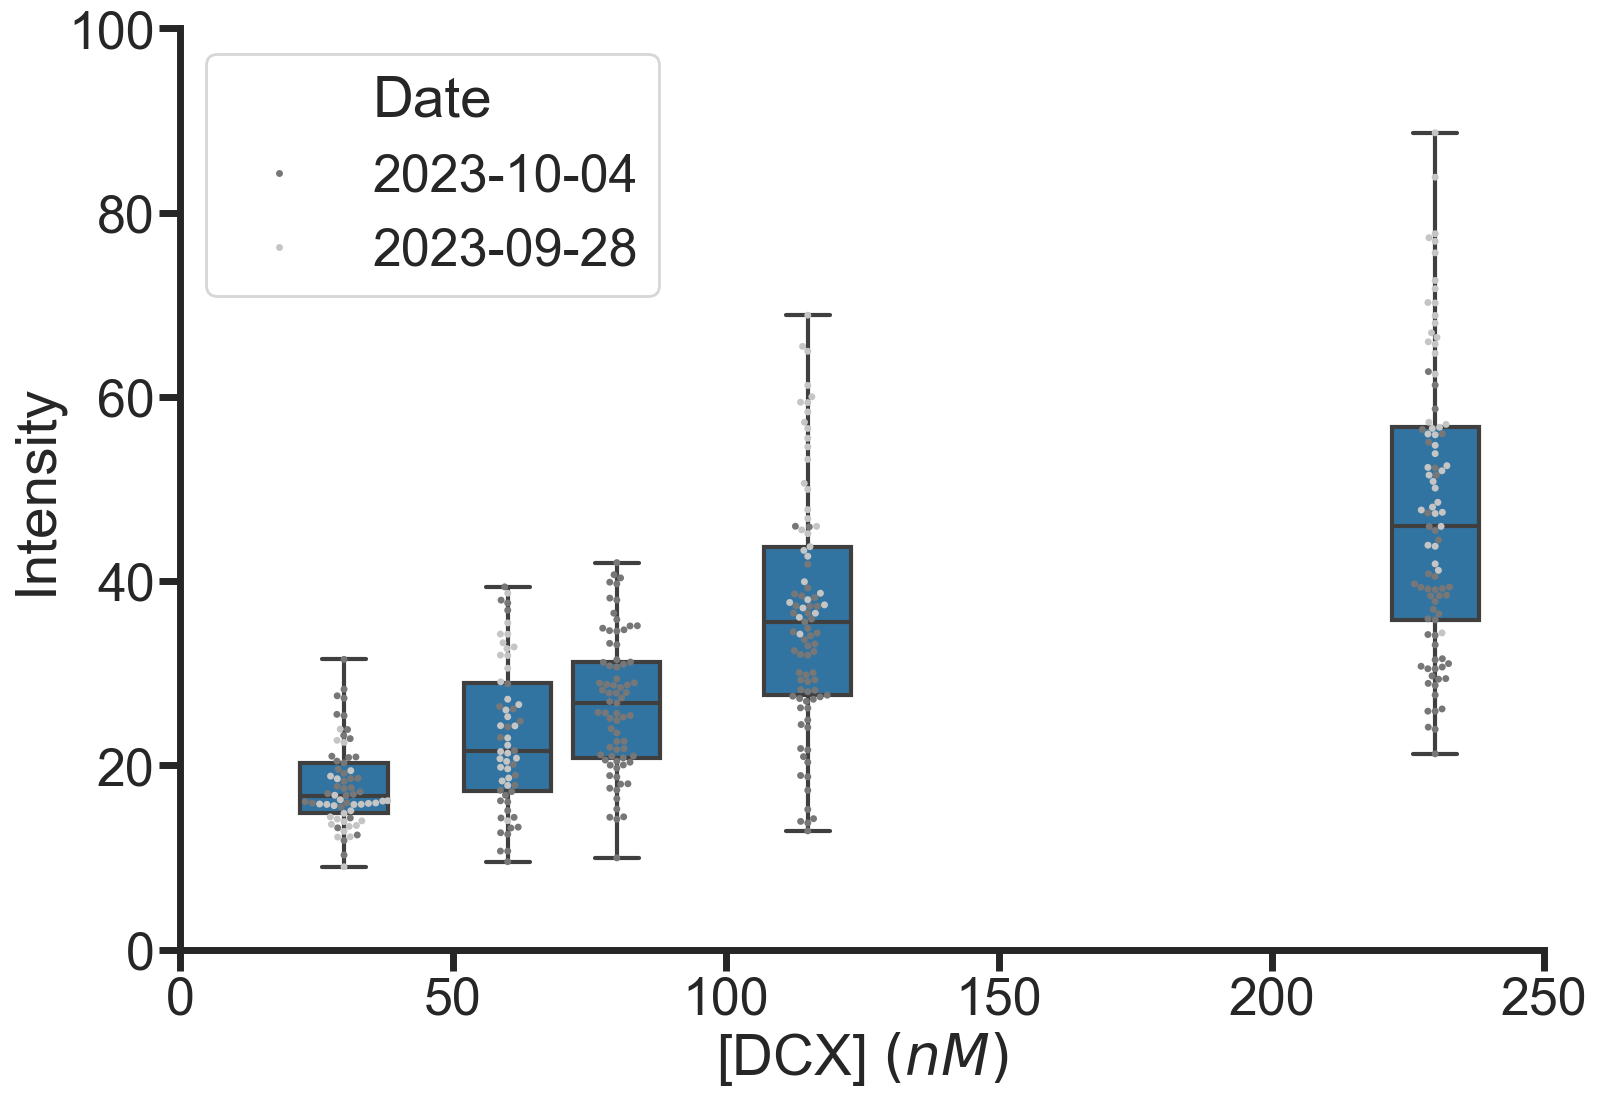

In [57]:
fig, ax = plt.subplots(1,1,figsize=(17,12))

# ax = sns.boxplot(x= DCXconc, y='Mean', data=data, whis=np.inf,linewidth=3,native_scale=True)
# ax = sns.swarmplot(x=DCXconc, y='Mean', data=data, hue='Date', size=5,native_scale=True , palette = [grey00, grey20])

ax = sns.boxplot(x= DCXconc, y='Intensity', data=data, whis=np.inf,linewidth=3,native_scale=True)
ax = sns.swarmplot(x=DCXconc, y='Intensity', data=data, hue='Date', size=5,native_scale=True , palette = [grey00, grey20])

#ax.legend( loc = 'lower right')
#ax.legend('')
ax.set_xlabel(DCXconc)

ax.set_xlim(0,100) 
ax.set_ylim(0,100) 
ax.set_xticks(np.arange(0, 251, 50))
sns.set_style("ticks")
sns.despine()
ax.spines['left'].set_lw(5)
ax.spines['bottom'].set_lw(5)
ax.tick_params(axis='both', width = 5, length = 15)
sns.set_context("poster", font_scale=1.7, rc={"lines.linewidth":3.0})

plt.tight_layout()


plt.savefig(newmydir/('intensity_'+date+'.svg'),backend='Cairo')
plt.savefig(newmydir/('intensity_'+date+'.png'),backend='Cairo')

In [129]:
datamean = data.groupby(by=DCXconc)[["Intensity", DCXconc]].mean()
datastd = data.groupby(by=DCXconc)[["Intensity", DCXconc]].std()

In [130]:
datamean

,Intensity,[DCX] $(n M)$
[DCX] $(n M)$,,
30,17.765138,30.0
60,23.234559,60.0
80,26.608397,80.0
115,36.465775,115.0
230,47.672720,230.0


In [131]:
x = datamean[DCXconc].values
y = datamean['Intensity'].values
yerr = datastd['Intensity'].values

In [132]:
p, cov = np.polyfit(x, y, 1, cov=True)
var = np.diagonal(cov) #Refer [3]
SElin = np.sqrt(var) #Refer [4]

m,b = p

p, SElin

(array([ 0.14946166, 14.95476762]), array([0.0185681 , 2.30461505]))

In [95]:
#R2S(y,x*m+b)

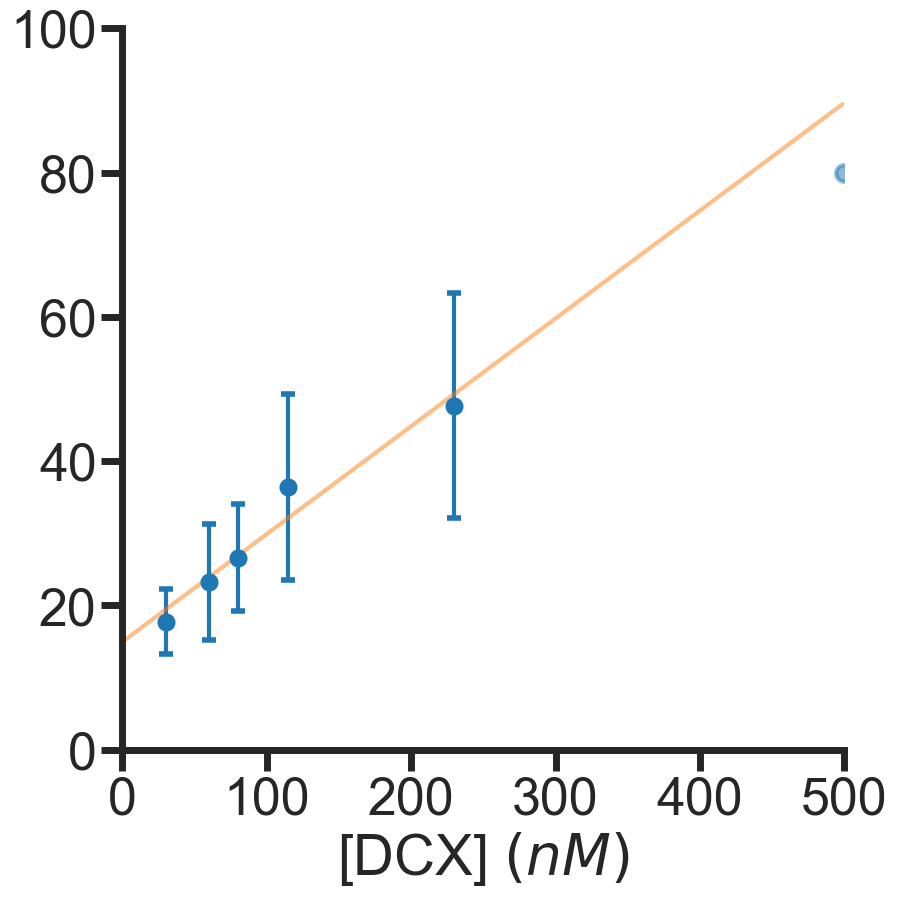

In [145]:
fig, ax = plt.subplots(1,1,figsize=(10,10))

scattersize = 9
cap = 5

ax.errorbar(x , y , yerr= yerr , fmt='',marker='o', markersize=scattersize,capsize = cap,
                              markeredgewidth=4, alpha = 1, ls='')

x0 = np.arange(0, 500, 1)
ax.plot(x0, x0*m+b, lw=3,ls= '-',alpha = 0.5)
ax.scatter([500], [80], lw=3,ls= '-',alpha = 0.5)
#ax.legend( loc = 'lower right')
#ax.legend('')
ax.set_xlabel(DCXconc)

ax.set_xlim(0,500) 
ax.set_ylim(0,100) 
ax.set_xticks(np.arange(0, 501, 100))
sns.set_style("ticks")
sns.despine()
ax.spines['left'].set_lw(5)
ax.spines['bottom'].set_lw(5)
ax.tick_params(axis='both', width = 5, length = 15)
sns.set_context("poster", font_scale=1.7, rc={"lines.linewidth":3.0})

plt.tight_layout()


# plt.savefig(newmydir/('intensity_mean'+date+'.svg'),backend='Cairo')
# plt.savefig(newmydir/('intensity_mean'+date+'.png'),backend='Cairo')

In [126]:
fakepointmean = datamean['Intensity'].iloc[[4]].values
fakepointmean = datastd['Intensity'].iloc[[4]].values

In [127]:
new_row_mean = {'Intensity':0, DCXconc:0}
new_row_std = {'Intensity':fakepointstd[0]0, DCXconc:150}
datamean2 = pd.concat([datamean, pd.DataFrame([new_row_mean])], ignore_index=True)
datastd2 = pd.concat([datastd, pd.DataFrame([new_row_std])], ignore_index=True)

In [128]:
datamean2

,Intensity,[DCX] $(n M)$
0,17.765138,30.0
1,23.234559,60.0
2,26.608397,80.0
3,36.465775,115.0
4,47.672720,230.0
5,14.596210,150.0


In [119]:
x = datamean2[DCXconc].values
y = datamean2['Intensity'].values
yerr = datastd2['Intensity'].values

In [120]:
def hillEQ(x, n, kd):
    return  (y[-1]) * np.power(x, n)/(kd + np.power(x, n))

In [121]:
coeff, var_matrix = sp.optimize.curve_fit(hillEQ,x,y)

variance = np.diagonal(var_matrix) #Refer [3]
SE = np.sqrt(variance)
C1L, C2L = coeff
coeff,SE

(array([  1.72666022, 938.83866384]), array([5.06891691e-01, 2.01972636e+03]))

In [111]:
logx = np.log(x[1:-1])
normy =( y[1:-1]-y[0])/(y[-1]-y[0])
logy = np.log(normy/(1-normy))

p, cov = np.polyfit(logx, logy, 1, cov=True)
var = np.diagonal(cov) #Refer [3]
SElin = np.sqrt(var) #Refer [4]

m,b = p


normyerr = ( YerrL[1:-1]-YerrL[0])/(YerrL[-1]-YerrL[0])
logyerr = np.power(1/(1-normy),2)*normyerr

p, SElin

C:\Users\Brouhard Lab\AppData\Local\Temp\ipykernel_7328\4193159431.py:3: RuntimeWarning: invalid value encountered in log
  logy = np.log(normy/(1-normy))


LinAlgError: SVD did not converge in Linear Least Squares

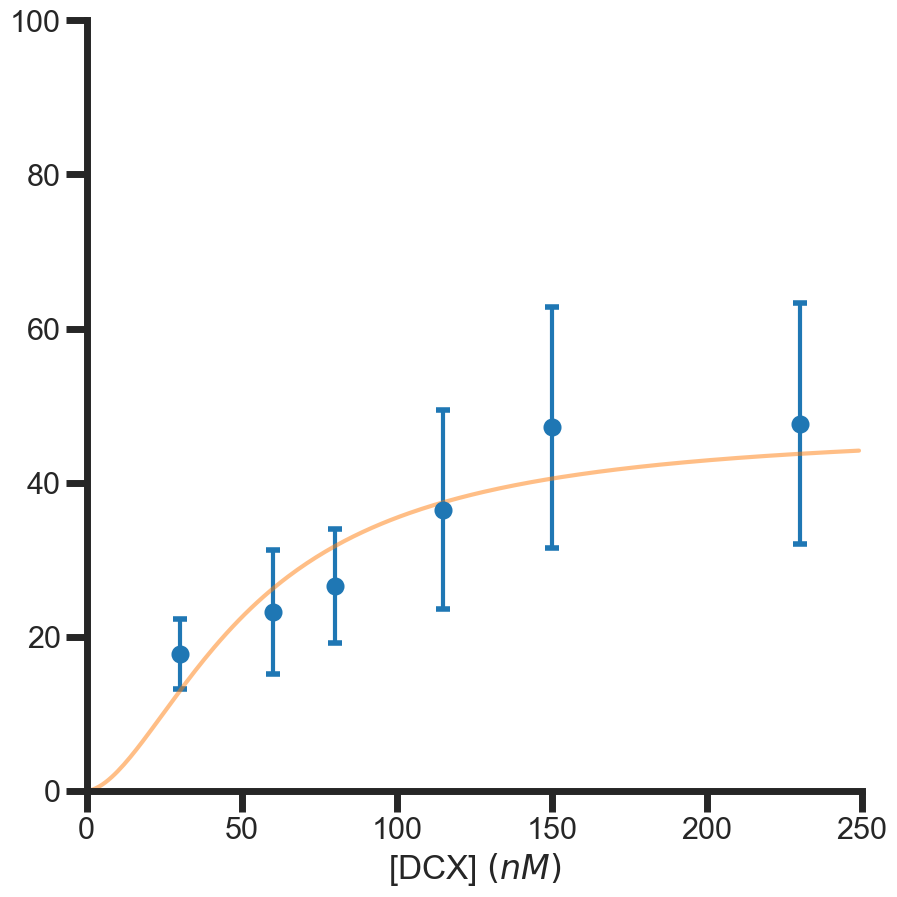

In [122]:
fig, ax = plt.subplots(1,1,figsize=(10,10))

scattersize = 9
cap = 5

ax.errorbar(x , y , yerr= yerr , fmt='',marker='o', markersize=scattersize,capsize = cap,
                              markeredgewidth=4, alpha = 1, ls='')

x0 = np.arange(0, 250, 1)
ax.plot(x0, hillEQ(x0,C1L, C2L), lw=3,ls= '-',alpha = 0.5)

# x0 = np.arange(0, 250, 1)
# ax.plot(x0, x0*m+b, lw=3,ls= '-',alpha = 0.5)
#ax.legend( loc = 'lower right')
#ax.legend('')
ax.set_xlabel(DCXconc)

ax.set_xlim(0,100) 
ax.set_ylim(0,100) 
ax.set_xticks(np.arange(0, 251, 50))
sns.set_style("ticks")
sns.despine()
ax.spines['left'].set_lw(5)
ax.spines['bottom'].set_lw(5)
ax.tick_params(axis='both', width = 5, length = 15)
sns.set_context("poster", font_scale=1.7, rc={"lines.linewidth":3.0})

plt.tight_layout()


plt.savefig(newmydir/('intensity_mean'+date+'.svg'),backend='Cairo')
plt.savefig(newmydir/('intensity_mean'+date+'.png'),backend='Cairo')

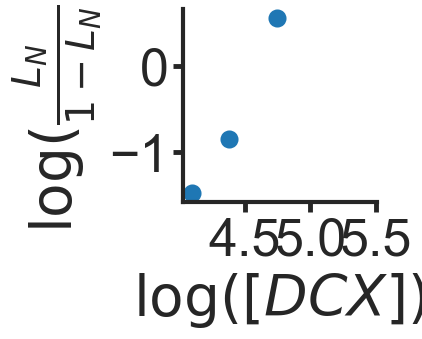

In [118]:
scattersize = 9
cap = 5

fig, ax = plt.subplots(1,1,figsize=(2.5,2.5))
ax.errorbar(logx , logy , yerr= 0 , fmt='',marker='o', markersize=scattersize,capsize = cap,
                              markeredgewidth=4, alpha = 1, ls='')

x0 = np.arange(3.3, 4.8, 0.05)
#ax.plot(x0, x0*m+b, lw=3,ls= '-',alpha = 0.5)

# ax.set_ylim(-2.5,2.5)
# ax.set_xlim(3,6)
ax.set_xlabel(r'$\log([DCX])$')
#ax.set_xticks(np.arange(0, 22.1, 2))
#ax.set_yticks(np.arange(0, 150.1, 25))
ax.set_ylabel(r'$\log(\frac{L_N}{1-L_N})$') 
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_lw(3)
ax.spines['bottom'].set_lw(3)
ax.tick_params(axis='both', width = 3.5, length = 7)

#ax.legend((r'$n=2.94 \pm 0.49$' '\n' r'$R^2 > 0.945$',),loc='lower right',title='Hill Equation')

sns.set_context("poster", font_scale=1, rc={"lines.linewidth":3.0})

#plt.savefig(newmydir/('logexpHillfit_Lifetime_'+date+'.svg'))